<a href="https://colab.research.google.com/github/AmatHub21/Latihan-Esmeble_Sklearn_byest-/blob/main/PENGUKURAN%20KEDEKATAN%20DAN%20SIMILARITAS%20DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Generate dataset imbalanced (90% kelas 0, 10% kelas 1)
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.9, 0.1], random_state=42)

# 2. Split data dengan stratifikasi agar proporsi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Prediksi
y_pred = model.predict(X_test)

# 5. Hitung dan cetak metrik
print("=" * 50)
print(" EVALUASI MODEL ")
print("=" * 50)
print(f" Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f" Precision : {precision_score(y_test, y_pred):.4f}")
print(f" Recall : {recall_score(y_test, y_pred):.4f}")
print(f" F1 - Score : {f1_score(y_test, y_pred):.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix :")
print(cm)
print("( Format : [[ TN, FP ], [ FN, TP ]])")

# 7. Classification Report lengkap
print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 8. Interpretasi manual dari Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretasi :")
print(f" True Negatives : {tn}")
print(f" False Positives : {fp}")
print(f" False Negatives : {fn}")
print(f" True Positives : {tp}")

 EVALUASI MODEL 
 Accuracy : 0.9533
 Precision : 0.8696
 Recall : 0.6452
 F1 - Score : 0.7407

Confusion Matrix :
[[266   3]
 [ 11  20]]
( Format : [[ TN, FP ], [ FN, TP ]])

Classification Report :
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97       269
     Class 1       0.87      0.65      0.74        31

    accuracy                           0.95       300
   macro avg       0.91      0.82      0.86       300
weighted avg       0.95      0.95      0.95       300


Interpretasi :
 True Negatives : 266
 False Positives : 3
 False Negatives : 11
 True Positives : 20


 AUC Score : 0.9076


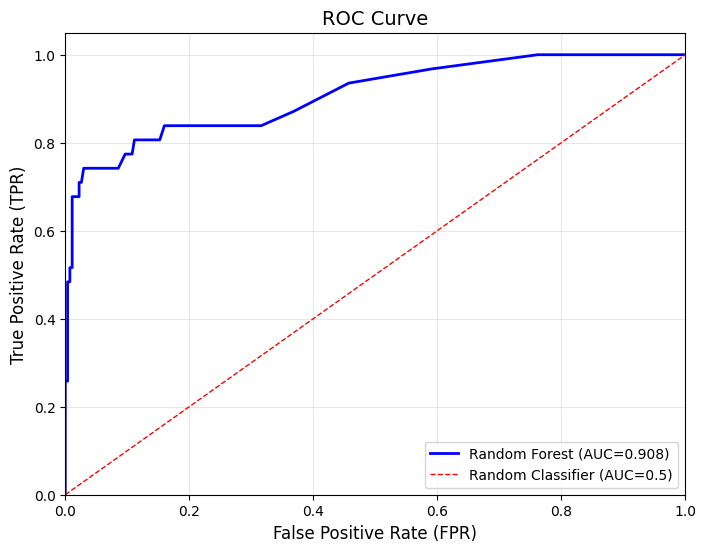

 Optimal threshold (Youden’s J) : 0.3300
 TPR at optimal threshold : 0.7419
 FPR at optimal threshold : 0.0297


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Dapatkan probabilitas untuk kelas positif
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Hitung ROC curve dan AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f" AUC Score : {auc:.4f}")

# 3. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 4. Cari threshold optimal (Youden’s J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f" Optimal threshold (Youden’s J) : {optimal_threshold:.4f}")
print(f" TPR at optimal threshold : {tpr[optimal_idx]:.4f}")
print(f" FPR at optimal threshold : {fpr[optimal_idx]:.4f}")

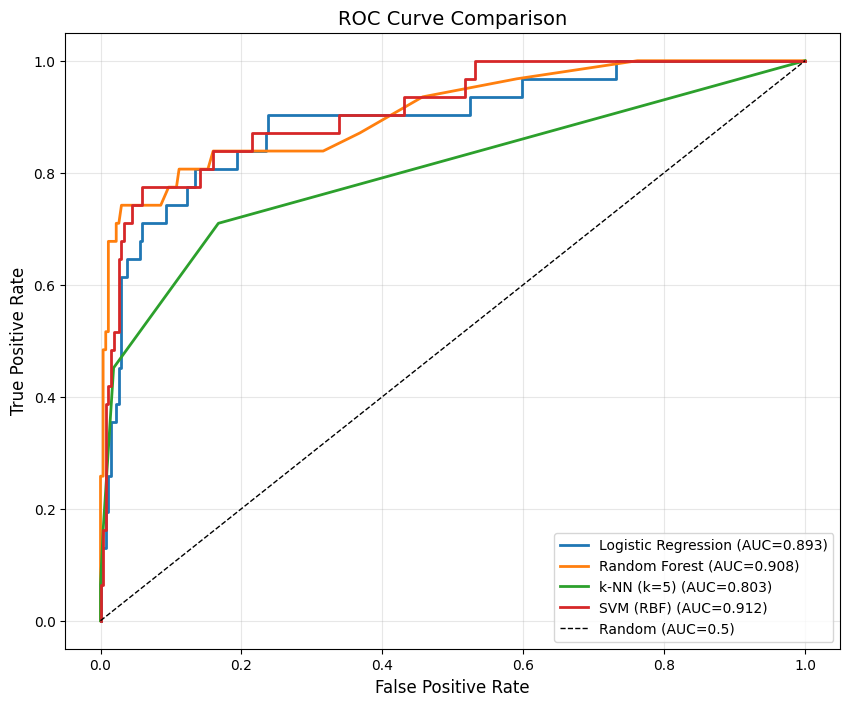

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Definisikan daftar model
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# 2. Train dan plot ROC masing-masing model
plt.figure(figsize=(10, 8))
for name, model_item in models.items():
    model_item.fit(X_train, y_train)
    y_proba_item = model_item.predict_proba(X_test)[:, 1]
    fpr_item, tpr_item, _ = roc_curve(y_test, y_proba_item)
    auc_item = roc_auc_score(y_test, y_proba_item)
    plt.plot(fpr_item, tpr_item, linewidth=2, label=f'{name} (AUC={auc_item:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

# 1. HOLD-OUT VALIDATION (Diulang 10 kali)
print("=" * 50)
print(" HOLD - OUT VALIDATION ")
print("=" * 50)
scores_holdout = []
for i in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=i)
    model_cv = RandomForestClassifier(random_state=42)
    model_cv.fit(X_tr, y_tr)
    scores_holdout.append(model_cv.score(X_te, y_te))
print(f" Mean accuracy : {np.mean(scores_holdout):.4f}")
print(f" Std : {np.std(scores_holdout):.4f}")

# 2. STANDARD K-FOLD CV
print("\n" + "=" * 50)
print(" K-FOLD CROSS VALIDATION ")
print("=" * 50)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
print(f" k-Fold (k=5) - Mean : {scores_kfold.mean():.4f} (+/- {scores_kfold.std():.4f})")

# 3. STRATIFIED K-FOLD CV (Sangat disarankan untuk dataset tidak seimbang)
print("\n" + "=" * 50)
print(" STRATIFIED K-FOLD CV ")
print("=" * 50)
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')
print(f" Stratified k-Fold - Mean : {scores_strat.mean():.4f} (+/- {scores_strat.std():.4f})")

# 4. Perbandingan untuk berbagai nilai k
k_values = [3, 5, 7, 10]
for k in k_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    print(f" k={k}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

 HOLD - OUT VALIDATION 
 Mean accuracy : 0.9487
 Std : 0.0093

 K-FOLD CROSS VALIDATION 
 k-Fold (k=5) - Mean : 0.9540 (+/- 0.0080)

 STRATIFIED K-FOLD CV 
 Stratified k-Fold - Mean : 0.9530 (+/- 0.0117)
 k=3: Mean = 0.9450, Std = 0.0135
 k=5: Mean = 0.9530, Std = 0.0117
 k=7: Mean = 0.9530, Std = 0.0148
 k=10: Mean = 0.9490, Std = 0.0170


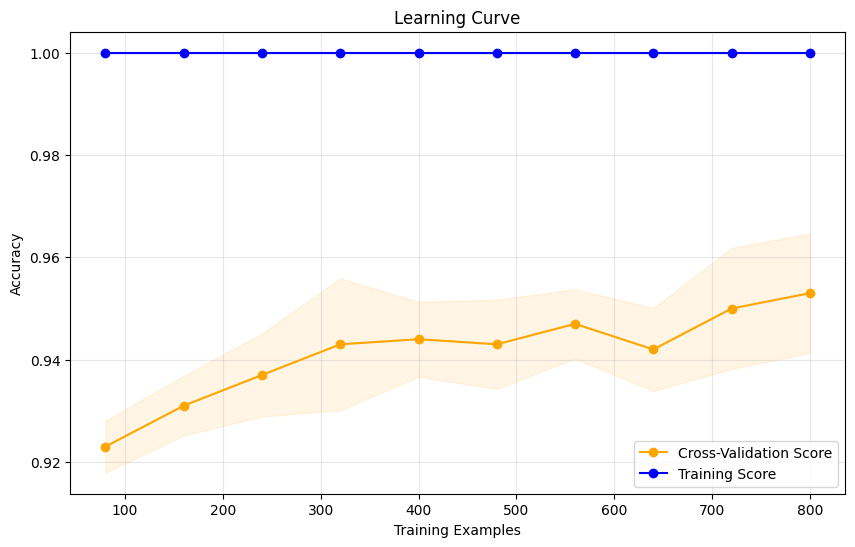

 MODEL GOOD : Training ~ Validation 


In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier

# 1. Hitung learning curve
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# 2. Hitung mean dan std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# 4. Interpretasi otomatis
gap = train_mean[-1] - test_mean[-1]
if gap > 0.1:
    print(" MODEL OVERFITTING : Training >> Validation ")
elif gap < -0.05:
    print(" MODEL UNDERFITTING : Training < Validation ")
else:
    print(" MODEL GOOD : Training ~ Validation ")